
# Inversion with structural constraints

In [10]:
%matplotlib widget

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
import os

First we load the data and the interface

In [12]:
os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas')
print(f'Directory: {os.getcwd()}')  # shows current working directory
os.makedirs(r"figures/line01/constraints", exist_ok=True)

filename = r'data\line01\og_fromtomsnotes_mytopo\project_5\Dipole-Dipole_1-2018-06-11-161704.dat'
data = ert.load(filename)
print(data)

02/03/26 - 09:47:11 - pyGIMLi - INFO - could not read unified data format for ERT ... try res2dinv


Directory: C:\Users\sydne\git\erth370\erth370-w2026-sydpas
Data: Sensors: 81 data: 1469, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid']


In [13]:
xs = np.array([s.x() for s in data.sensors()])  # an array of all elec x-positions along line

data_min = xs.min(); data_max = xs.max()

print(data_min, data_max)

0.0 400.0


adding "topo = topo[np.argsort(topo[:,0])]"  to deal w negative vals


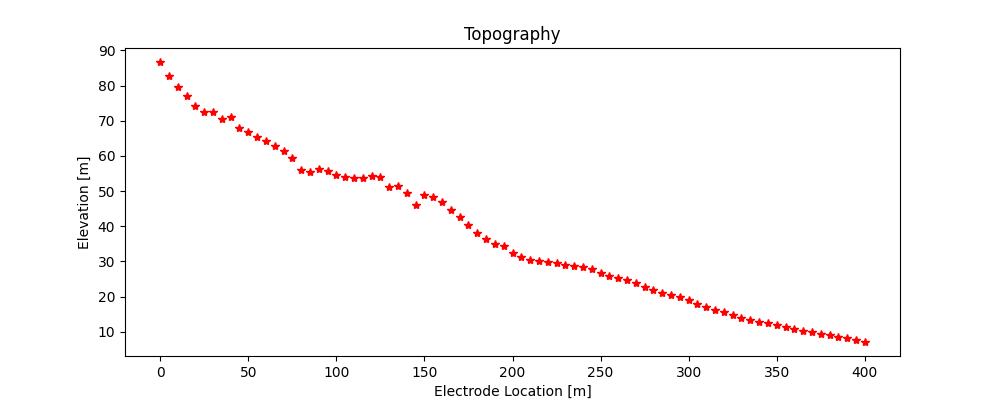

In [14]:
topo = []

topo_file = r'data\line01\og_fromtomsnotes_mytopo\line01_mytopo.txt'

with open(topo_file) as f: 
    next(f)  # skip header line
    for line in f:
        line = line.strip()
        parts = line.split()  # split using whitespace
        if len(parts) == 2:  # if data has 2 columns it is topo data so add to the list
            topo.append([float(parts[0]), float(parts[1])])

topo = np.array(topo)  # convert to numpy array

x_elec = pg.x(data)  # get x pos of all electrodes
z_elec = np.interp(x_elec, topo[:,0], topo[:,1])  # interpolate topo at each electrode

x_elec = np.array(pg.x(data))  # convert RVector to numpy

# now we ensure topo covers all electrodes at both ends
if topo[0,0] > x_elec.min():  # if topo is to the right of (after) electrode
    topo = np.vstack(([x_elec.min(), topo[0,1]], topo))
if topo[-1,0] < x_elec.max():  # if topo is to the left of (before) electrode
    topo = np.vstack((topo, [x_elec.max(), topo[-1,1]]))

# print(f'x elec: {x_elec}')
# print(f'topo[:,0]: {topo[:,0]}')
# print(f'topo[:,1]: {topo[:,1]}')


# second interp of topo at electrode positions
z_interp = np.interp(x_elec, topo[:,0], topo[:,1])

# print(f'z interp: {z_interp}')

# set electrode positions in data
data.setSensorPositions(pg.PosVector(np.c_[x_elec, z_interp]))  # combine into 2D array, convert to gimli pos vector, and update elec pos in ERT dataset

# plot to check
fig, ax = plt.subplots(figsize=(10,4)) 
ax.plot(x_elec, z_interp, 'r*')
ax.set_xlabel('Electrode Location [m]')
ax.set_ylabel('Elevation [m]')
ax.set_title('Topography')

plt.show()

Now we will make a graph!! And show the data woohoo

02/03/26 - 09:47:20 - pyGIMLi - CRITICAL - None.showERTData(c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\physics\ert\visualization.py:102)
field not in data container:  rhoa


Exception: field not in data container:  rhoa

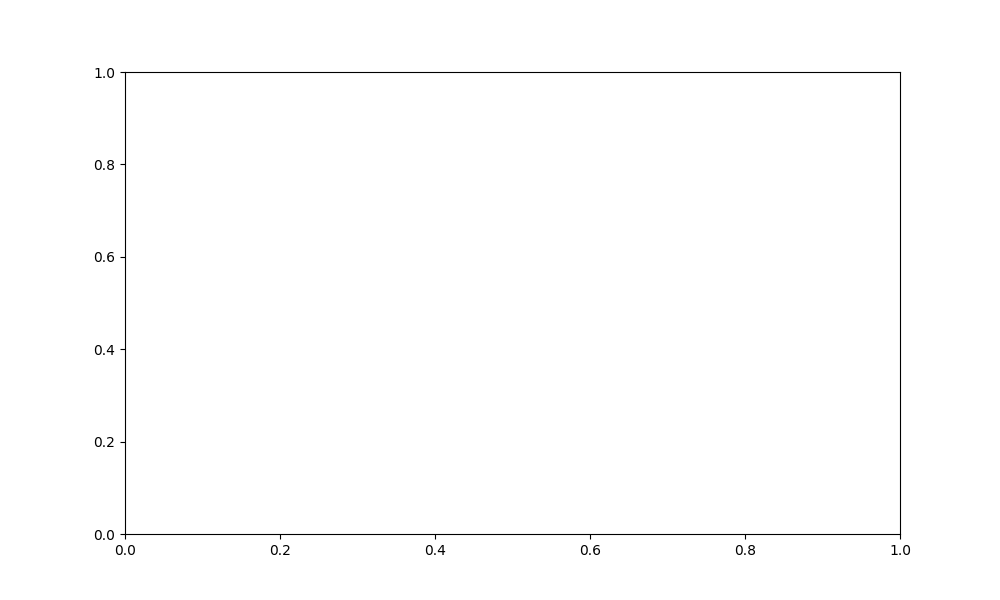

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

_ = ert.showData(data,
                ax=ax,
                logScale=True,
)

ax.set_title('ERT Data with Apparent Resistivity');

We estimate an error and do a normal inversion using the ERT manager.
As we expect more or less layered structures, we choose a vertical
weighting factor for the regularization of 0.5.




02/03/26 - 09:41:59 - pyGIMLi - INFO - Cache c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 1): C:\Users\sydne\AppData\Roaming\pygimli\Cache\9782893562232282285


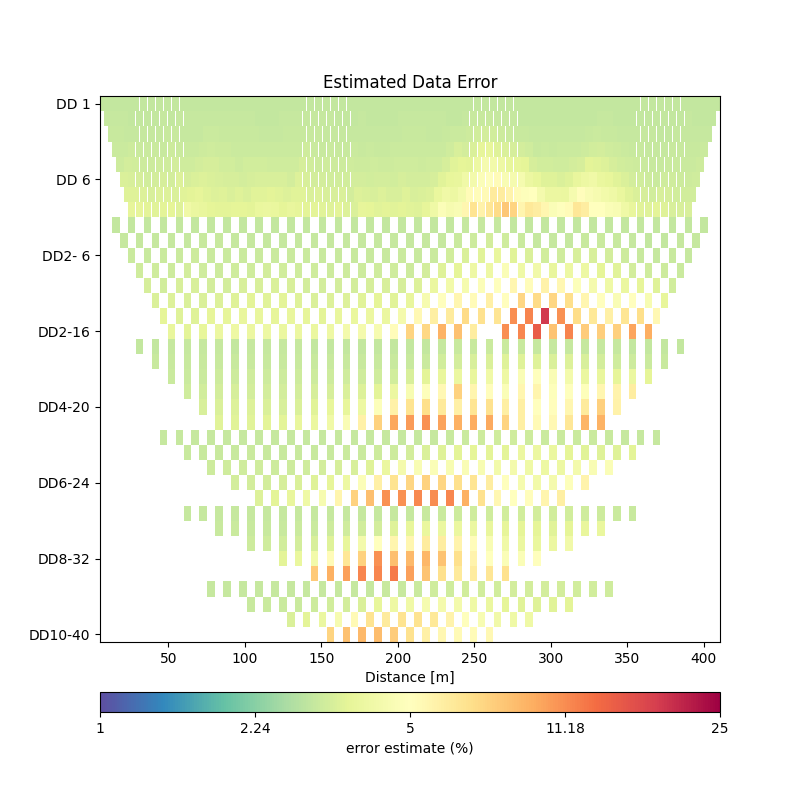

In [9]:
data.estimateError(relativeError=0.03, absoluteUError=5e-5)

fig, ax = plt.subplots(figsize=(8,8))
_ = data.show( data['err']*100, ax=ax,
    label='error estimate (%)', xlabel='Distance [m]',
    cMin=1, cMax=25)

ax.set_title('Estimated Data Error');

We plot the inversion result using a defined color scale.
Additionally, we plot the measured line on top of it and see that generally
there is a change from conductive overburden to resistive bedrock.




In [9]:
def onclick(event):
    # make sure click is inside the correct axes
    if event.inaxes != ax:
        return

    if event.xdata is not None and event.ydata is not None:
        x_line.append(event.xdata)
        z_line.append(event.ydata)

        ax.plot(event.xdata, event.ydata, 'bo', markersize=5)  # plot on SAME axes
        fig.canvas.draw_idle()

        print(f"Picked point: x={event.xdata:.2f}, z={event.ydata:.2f}")


In [1]:
# lists to store clicked points
x_line = []
z_line = []

data.estimateError()
mgr = ert.Manager(data)
mgr.invert(paraDepth=100, zWeight=0.5, verbose=True)

ax, cb = mgr.showResult(cMin=150, cMax=1500, cMap = 'viridis')  # plot the inverted resistivity model

ax.set_title('Inverted Resistivity Model', fontsize=14)

fig = ax.figure  

# connect click handler to the SAME figure
cid = fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()


NameError: name 'data' is not defined

In [12]:
fig.canvas.mpl_disconnect(cid)

plt.ion()

print(x_line)
print(z_line)

[]
[]


We now want to include this line into the inversion mesh.
Therefore we generate the geometry of the inversion, a polygone from the line
and merge both objects before we send it to the mesh generation.

For line = mt.createPolygon...
- if 1: boundary contraint
- if >1: internal structure (bedrock)
- to clip for fault:
    xmin, xmax = 0, 200
    xz_clip = xz[(xz[:, 0] >= xmin) & (xz[:, 0] <= xmax)]
    line = mt.createPolygon(xz_clip, marker=2)


In [ ]:
xz = np.column_stack([x_line, z_line])

# make sure line in domain
xmin, xmax = data.sensorPositions()[:,0].min(), data.sensorPositions()[:,0].max()
xz = xz[(xz[:, 0] >= xmin) & (xz[:, 0] <= xmax)]
xz[:, 1] -= 0.5  # ensure not to hit the surface

# build a piecewise linear complex (PLC) for meshing based on electrode pos
plc = mt.createParaMeshPLC(data, paraDepth=30, boundary=1)

# turn the xz points into polyline from topography or structure
line = mt.createPolygon(xz, marker=2)

plc += line

# generates the finite element mesh
mesh = mt.createMesh(plc, quality=34.3)  

ax, _ = pg.show(mesh, markers=True, showMesh=True)
ax.set_title('Finite Element Mesh with Constraint Added', fontsize=14);


We see the outer boundaries have markers of -1 (homogeneous Neumann, no-flow)
and -2 (mixed) important to define the boundary conditions of the forward
problem. The interface between the inversion domain (yellow) and the outer
region (blue) and the added interface are >0 and do not affect the forward.
We now use the generated mesh in a new ERT manager by setting it.




06/02/26 - 16:31:36 - pyGIMLi - INFO - Found 2 regions.
06/02/26 - 16:31:36 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
06/02/26 - 16:31:36 - pyGIMLi - INFO - Creating forward mesh from region infos.
06/02/26 - 16:31:36 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
06/02/26 - 16:31:36 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 4677 Cells: 8936 Boundaries: 6910
06/02/26 - 16:31:36 - pyGIMLi - INFO - Use median(data values)=358.25014999999996
06/02/26 - 16:31:36 - pyGIMLi - INFO - Created startmodel from forward operator:1654, min/max=358.250150/358.250150
06/02/26 - 16:31:36 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001A92057BBF0>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 125/1093
min/max (error): 3%/3%
min/max (start model): 358/358
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  198.25
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   57.55 (dPhi = 70.28%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   18.79 (dPhi = 66.34%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =   10.81 (dPhi = 41.01%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    6.32 (dPhi = 39.13%) lam: 20.0
--------------------------------------------------------

Text(0.5, 1.0, 'Re-Inverted Resistivity Model with Constraint Added')

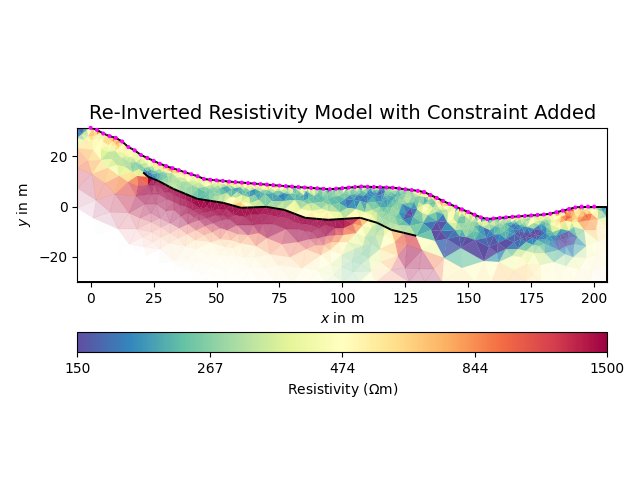

In [87]:
mgr = ert.Manager(data)
mgr.setMesh(mesh)
mgr.invert(verbose=True)
ax, cb = mgr.showResult(cMin=150, cMax=1500)

ax.set_title('Re-Inverted Resistivity Model with Constraint Added', fontsize=14)
